# Analisis exploratorio de datos

## Importacion de librerias

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro, normaltest, kstest

## funciones

In [50]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [51]:
def analizar_categoricas(df):
    resultados = []

    # Detectar variables categóricas (object, category o booleanas)
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)
        proporcion = df[col].value_counts(normalize=True, dropna=False)
        nulos = df[col].isna().sum()

        # Tomamos la categoría más frecuente
        categoria_moda = conteo.index[0] if not conteo.empty else None
        frecuencia_moda = conteo.iloc[0] if not conteo.empty else None

        resultados.append({
            "variable": col,
            "cantidad_categorias": df[col].nunique(dropna=False),
            "categoria_mas_frecuente": categoria_moda,
            "frecuencia_mas_frecuente": frecuencia_moda,
            "porcentaje_mas_frecuente": proporcion.iloc[0] if not conteo.empty else None,
            "nulos": nulos
        })
    
    return pd.DataFrame(resultados).sort_values(by="cantidad_categorias", ascending=False)

In [52]:
def GraficarCategoricas(df, tipo="barra"):
    # Detectar variables categóricas
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns
    resultados = {}

    if len(categoricas) == 0:
        print("No se detectaron variables categóricas en el DataFrame.")
        return

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)  # incluir NaN si hay
        resultados[col] = conteo

        if tipo == "barra":
            plt.figure(figsize=(6,4))
            conteo.plot(kind="bar", color="skyblue", edgecolor="black")
            plt.title(f"Frecuencia de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif tipo == "pastel":
            plt.figure(figsize=(6,6))
            conteo.plot(kind="pie", autopct='%1.1f%%', 
                        colors=plt.cm.Set3.colors, startangle=90)
            plt.title(f"Distribución de {col}")
            plt.ylabel("")
            plt.tight_layout()
            plt.show()
        else:
            raise ValueError("El parámetro 'tipo' debe ser 'barra' o 'pastel'.")

    return resultados

In [53]:
def resumen_numericas(df):
    # Seleccionar columnas numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    
    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None
    
    # Usamos describe() y agregamos info adicional
    resumen = df[numericas].describe().T  # Transpuesto para mayor claridad
    resumen["varianza"] = df[numericas].var()
    resumen["mediana"] = df[numericas].median()
    
    return resumen

In [54]:
def graficar_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return

    for col in numericas:
        plt.figure(figsize=(12,4))

        # Histograma
        plt.subplot(1,2,1)
        df[col].hist(bins=20, color="skyblue", edgecolor="black")
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

        # Boxplot
        plt.subplot(1,2,2)
        plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="lightgreen", color="black"),
                    medianprops=dict(color="red"))
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)

        plt.tight_layout()
        plt.show()

In [55]:
def contar_na_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None

    # Contar NAs en cada variable numérica
    na_counts = df[numericas].isna().sum()

    return na_counts


In [56]:
def detectar_outliers(df):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) == 0:
            continue

        # Cuartiles
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        # Límites para outliers
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        # Detección
        outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
        total = len(serie)

        resultados.append({
            "variable": col,
            "n_muestras": total,
            "outliers": outliers,
            "proporcion_outliers": outliers / total if total > 0 else np.nan
        })
    
    return pd.DataFrame(resultados).sort_values(by="proporcion_outliers", ascending=False)

In [73]:
def prueba_normalidad(df, alpha=0.05):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) < 8:  # muy pocas muestras → no confiable
            resultados.append({
                "variable": col,
                "n_muestras": len(serie),
                "shapiro_p": np.nan,
                "dagostino_p": np.nan,
                "ks_p": np.nan,
                "es_normal (alpha=0.05)": "Muestra insuficiente"
            })
            continue

        # Shapiro-Wilk (solo si n <= 5000, más grande no recomendado)
        stat_shapiro, p_shapiro = shapiro(serie) if len(serie) <= 5000 else (np.nan, np.nan)

        # D’Agostino y Pearson
        stat_dagostino, p_dagostino = normaltest(serie)

        # Kolmogorov-Smirnov contra normal estándar
        stat_ks, p_ks = kstest(
            (serie - serie.mean()) / serie.std(ddof=0), 'norm'
        )

        # Veredicto final
        es_normal = (
            (np.isnan(p_shapiro) or p_shapiro > alpha) and
            (p_dagostino > alpha) and
            (p_ks > alpha)
        )

        resultados.append({
            "variable": col,
            "n_muestras": len(serie),
            "shapiro_p": p_shapiro,
            "dagostino_p": p_dagostino,
            "ks_p": p_ks,
            "es_normal (alpha=0.05)": es_normal
        })

    return pd.DataFrame(resultados).sort_values(by="es_normal (alpha=0.05)", ascending=False)

## Introduccion

fuente de los datos: https://archive.ics.uci.edu/dataset/2/adult

### Descripcion general del dataset

- Conocido también como Census Income.

- Fue publicado en el UCI Machine Learning Repository por Barry Becker en 1996, a partir de datos del censo de EE. UU. de 1994.

- Tiene 48 842 instancias y 14 atributos.

### Atributos incluidos

- Age
- Fnlwgt (final weight)
- Education
- Education-num
- Capital-gain
- Capital-loss
- Hours-per-week
- Workclass
- Occupation
- Native-country
- Relationship
- Marital-status
- Race
- Sex
- Income

## Cargado de datos y exploraciones iniciales:

In [57]:
df1=pd.read_csv("adult.data",header=None,na_values=" ?")
df2=pd.read_csv("adult.test",header=None,na_values=" ?")

In [58]:
df1.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [59]:
df2.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


In [60]:
df = pd.concat([df1, df2], ignore_index=True)

In [61]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [62]:
cols = ["Age",
          "Workclass",
          "Fnlwgt",
          "Education",
          "Education-num",
          "Marital-status",
          "Occupation",
          "Relationship",
          "Race",
          "Sex",
          "Capital-gain",
          "Capital-loss",
          "Hours-per-week",
          "Native-country",
          "Income"]
df.columns = cols
df.head()

,Age,Workclass,Fnlwgt,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Cargamos el conjunto de datos desde las 2 tablas y como no es nuestro objetivo realizar tecnicas de machine learning juntamos los registros de train y test para formar un dataframe completo con toda la informacion.
Se observa ademas la falta de nombres representativos para las columnas lo cual acaba de ser arreglado

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             48842 non-null  int64 
 1   Workclass       46043 non-null  object
 2   Fnlwgt          48842 non-null  int64 
 3   Education       48842 non-null  object
 4   Education-num   48842 non-null  int64 
 5   Marital-status  48842 non-null  object
 6   Occupation      46033 non-null  object
 7   Relationship    48842 non-null  object
 8   Race            48842 non-null  object
 9   Sex             48842 non-null  object
 10  Capital-gain    48842 non-null  int64 
 11  Capital-loss    48842 non-null  int64 
 12  Hours-per-week  48842 non-null  int64 
 13  Native-country  47985 non-null  object
 14  Income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


ademas notamos que el tipo de dato está correctamente entendido por python en el caso de las variables numericas education-num(a pesar de ser un numero es una variable categorica) y la convertiremos a factor

In [64]:
df["Workclass"] = df["Workclass"].astype("category")
df["Education"] = df["Education"].astype("category")
df["Marital-status"] = df["Marital-status"].astype("category")
df["Occupation"] = df["Occupation"].astype("category")
df["Relationship"] = df["Relationship"].astype("category")
df["Race"] = df["Race"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Native-country"] = df["Native-country"].astype("category")
df["Income"] = df["Income"].astype("category")

In [65]:
df["Education-num"] = df["Education-num"].astype("category")

Ahora que ya finalizamos con el cargado y la validacion adecuada del tipo de dato podemos proseguir con un analisis exploratorio de datos con su respectivo analisis de datos faltantes

## Analisis exploratorio de datos

### Analisis exploratorio de datos para variables categoricas

In [66]:
Summary(df, "Datos")

Hoja: Datos

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,48842,15,6465,29



Encabezado:


,Age,Workclass,Fnlwgt,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [67]:
analizar_categoricas(df)

,variable,cantidad_categorias,categoria_mas_frecuente,frecuencia_mas_frecuente,porcentaje_mas_frecuente,nulos
8,Native-country,42,United-States,43832,0.897424,857
1,Education,16,HS-grad,15784,0.323164,0
2,Education-num,16,9,15784,0.323164,0
4,Occupation,15,Prof-specialty,6172,0.126367,2809
0,Workclass,9,Private,33906,0.694198,2799
3,Marital-status,7,Married-civ-spouse,22379,0.458192,0
5,Relationship,6,Husband,19716,0.403669,0
6,Race,5,White,41762,0.855043,0
9,Income,4,<=50K,24720,0.506122,0
7,Sex,2,Male,32650,0.668482,0


#### Grafica para las categoricas

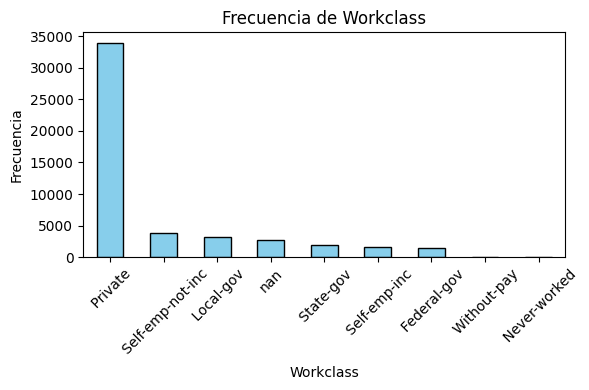

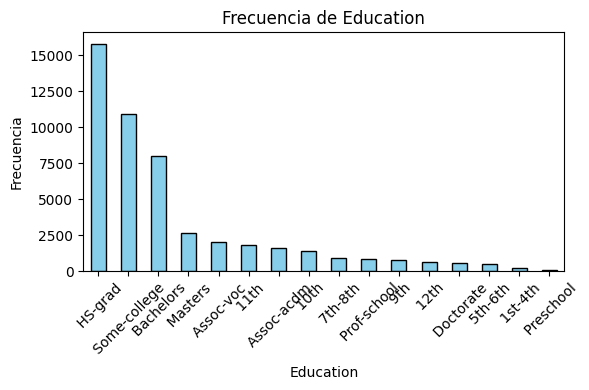

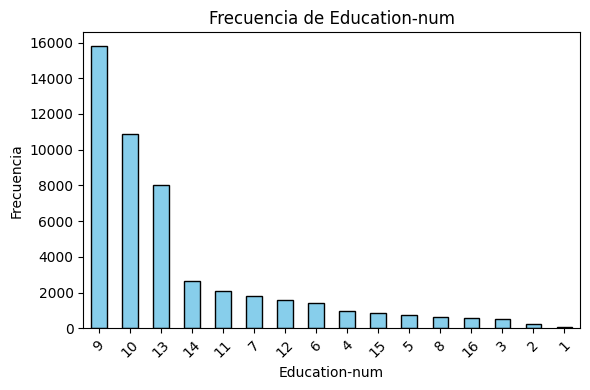

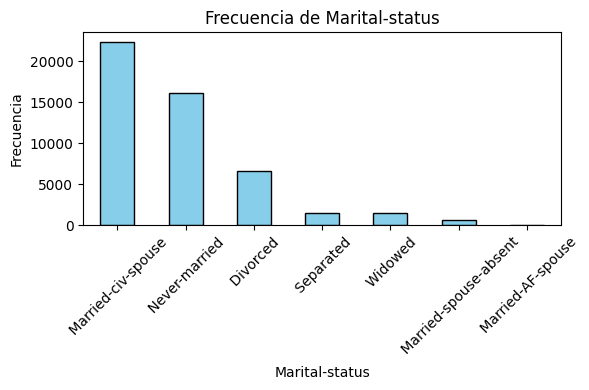

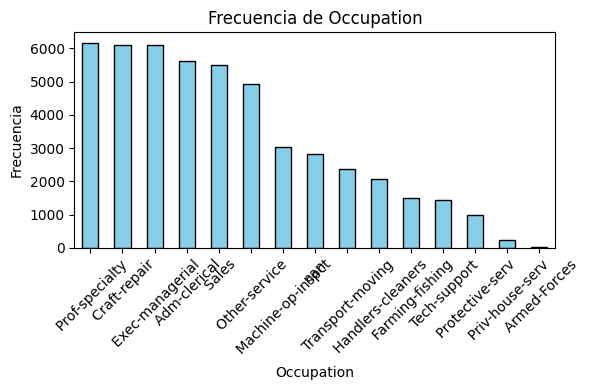

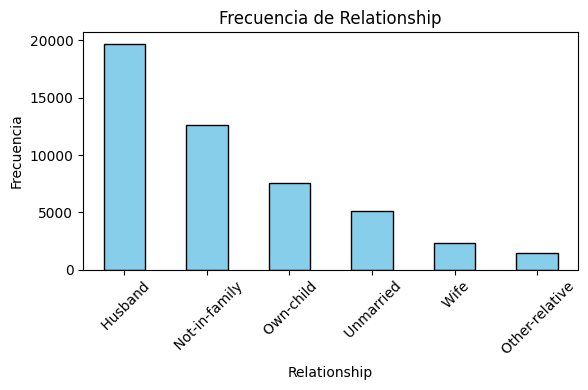

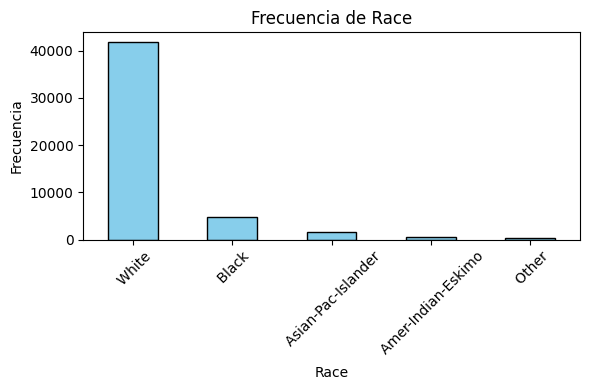

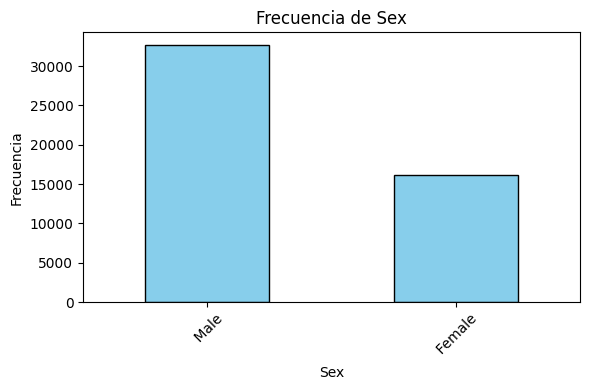

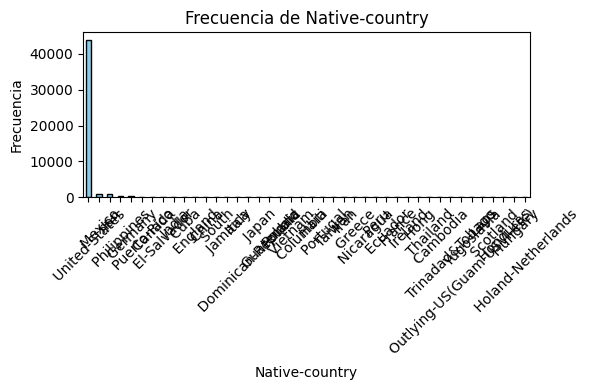

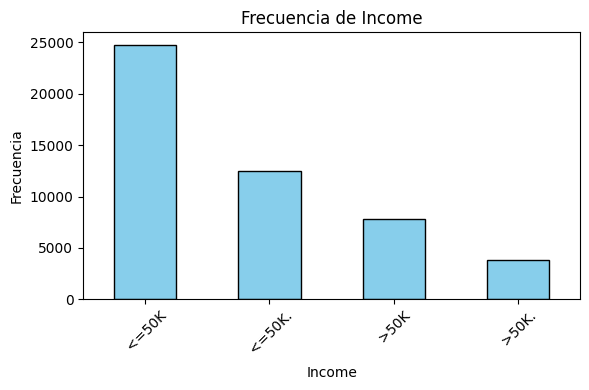

{'Workclass': Workclass
  Private             33906
  Self-emp-not-inc     3862
  Local-gov            3136
 NaN                   2799
  State-gov            1981
  Self-emp-inc         1695
  Federal-gov          1432
  Without-pay            21
  Never-worked           10
 Name: count, dtype: int64,
 'Education': Education
 HS-grad         15784
 Some-college    10878
 Bachelors        8025
 Masters          2657
 Assoc-voc        2061
 11th             1812
 Assoc-acdm       1601
 10th             1389
 7th-8th           955
 Prof-school       834
 9th               756
 12th              657
 Doctorate         594
 5th-6th           509
 1st-4th           247
 Preschool          83
 Name: count, dtype: int64,
 'Education-num': Education-num
 9     15784
 10    10878
 13     8025
 14     2657
 11     2061
 7      1812
 12     1601
 6      1389
 4       955
 15      834
 5       756
 8       657
 16      594
 3       509
 2       247
 1        83
 Name: count, dtype: int64,
 'Marita

In [68]:
GraficarCategoricas(df,"barra")

### Analisis exploratorio para variables numericas

In [69]:
resumen_numericas(df)

,count,mean,std,min,25%,50%,75%,max,varianza,mediana
Age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0,1.879781e+02,37.0
Fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0,1.115221e+10,178144.5
Capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0,5.553259e+07,0.0
Capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0,1.624127e+05,0.0
Hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0,1.535479e+02,40.0


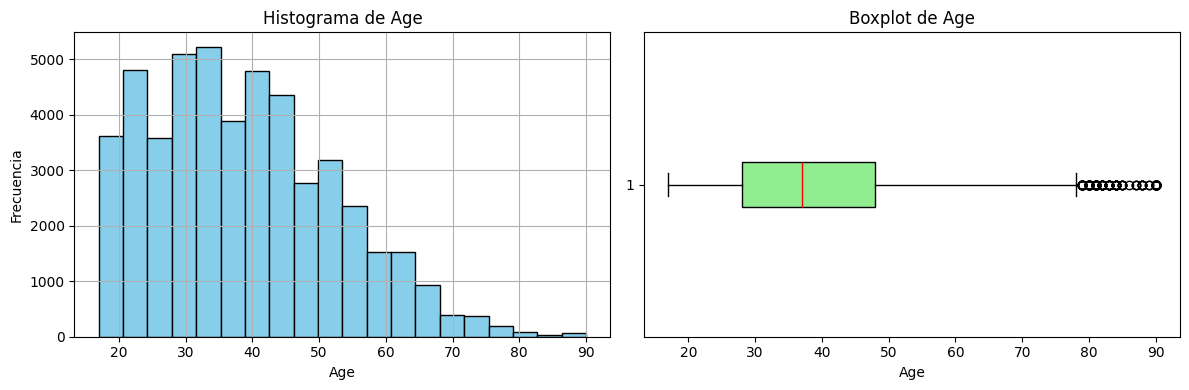

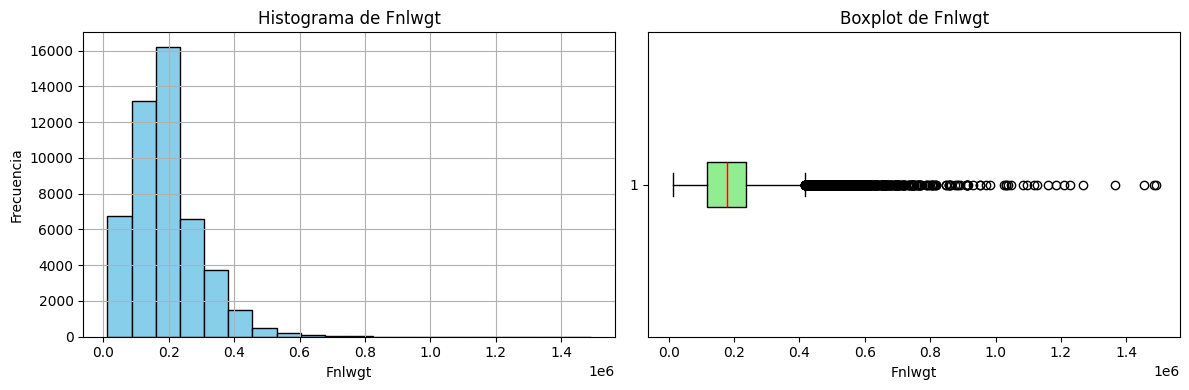

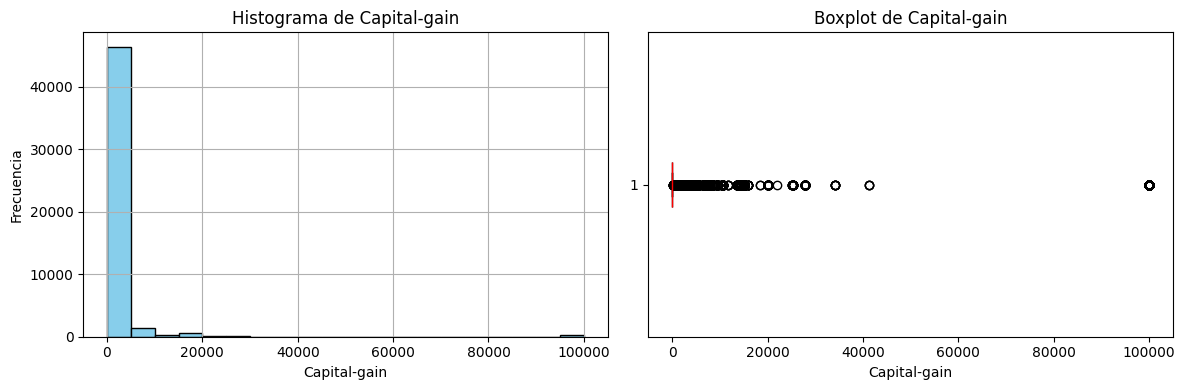

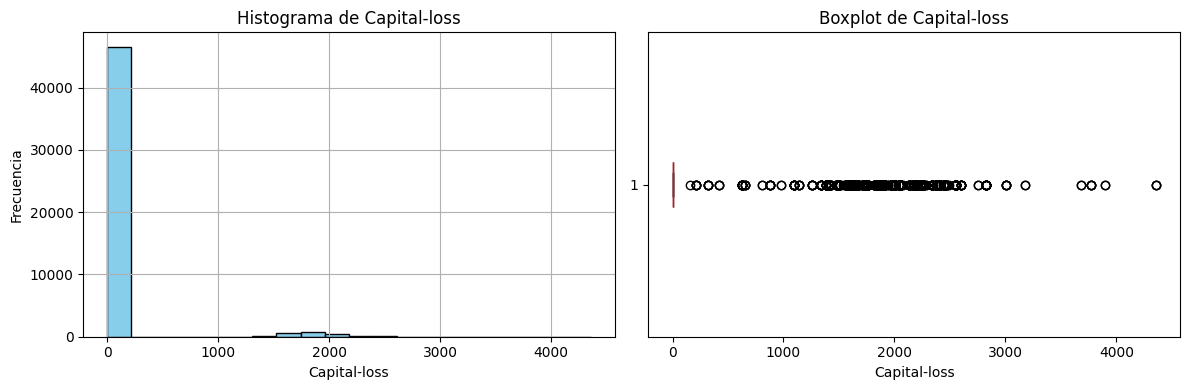

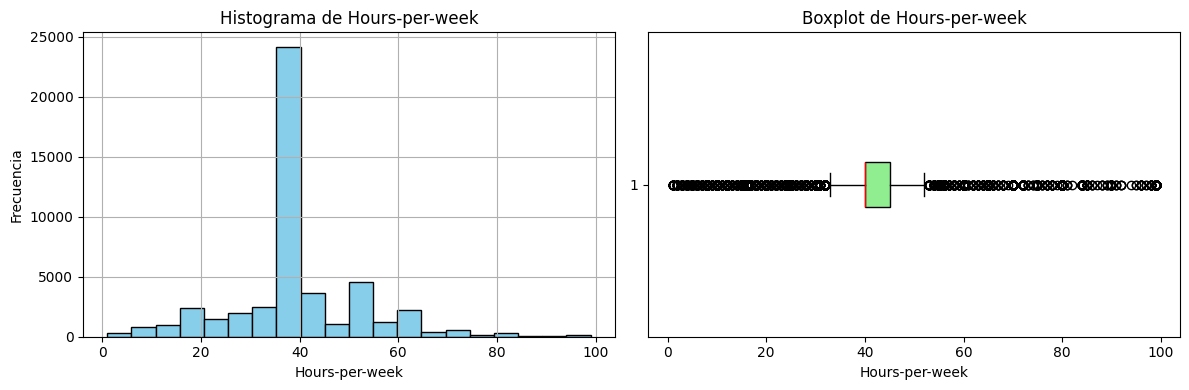

In [70]:
graficar_numericas(df)

In [71]:
contar_na_numericas(df)

Age               0
Fnlwgt            0
Capital-gain      0
Capital-loss      0
Hours-per-week    0
dtype: int64

### Conclusiones del exploratorio de datos inicial/univariado

- Se observa la presencia de datos atipicos para las variables numericas y presencia de datos Nan para las variables categoricas que deben ser tratados

## Analisis mediante pruebas analiticas

In [75]:
prueba_normalidad(df)

,variable,n_muestras,shapiro_p,dagostino_p,ks_p,es_normal (alpha=0.05)
0,Age,48842,NaN,0.0,8.040691e-170,False
1,Fnlwgt,48842,NaN,0.0,0.000000e+00,False
2,Capital-gain,48842,NaN,0.0,0.000000e+00,False
3,Capital-loss,48842,NaN,0.0,0.000000e+00,False
4,Hours-per-week,48842,NaN,0.0,0.000000e+00,False


## Analisis de outliers

In [72]:
detectar_outliers(df)

,variable,n_muestras,outliers,proporcion_outliers
4,Hours-per-week,48842,13496,0.276320
2,Capital-gain,48842,4035,0.082613
3,Capital-loss,48842,2282,0.046722
1,Fnlwgt,48842,1453,0.029749
0,Age,48842,216,0.004422


en todas las categorias salvo hours-per-week se ve una baja cantidad de outliers, por lo que realizaremos metodos de limpieza principalmente sencillos salvo para dicha variable

## Preprocesamiento de datos